# This notebook holds a comprehensive spectral analisis of the data. 
It loads the processed data and analise its spectral properties. The main analisys are:
- spectral information: it fetches the Mel-Spectrograms directly using the official `Dataset` class, which computes the STFT dynamically on the fly. It plots the spectrograms for a few samples.
- spectral statistics: it extracts the temporal-averaged mel embeddings across the dataset, computing the mean and variance to understand the variability in the data.
- spectral clustering: it applies K-means on the spectrogram embeddings to identify potential clusters, and visualizes them in a 2D space using PCA and t-SNE.
- As a future work, it will load the VERBO dataset and perform the same spectral analysis on it using the dataset class wrapper.

In [1]:
# ==========================================
# 1. SETUP AND IMPORTS
# ==========================================
import os
import sys
from pathlib import Path
import random

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Subset

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# Set project root and paths
PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "src" / "models" / "tacotron2_vae"))
sys.path.insert(0, str(PROJECT_ROOT / "src" / "training" / "training-tacotron2-vae"))
sys.path.insert(0, str(PROJECT_ROOT / "src" / "data" / "loader_vae_tacotron"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Project root: {PROJECT_ROOT}")

Using device: cuda
Project root: /home/richard/project/ml2_final_project


In [2]:
# ==========================================
# 2. DATA LOADING VIA OFFICIAL DATASET CLASS
# ==========================================
from text_processing import TextProcessor
from loader_tacotron import load_data

# Initialize the text processor
processor = TextProcessor()

# Path to the processed dataset directory
data_dir = Path("data/processed/libriSpeech-en-tacotron-vae")
if not data_dir.exists():
    print(f"Warning: {data_dir} not found. Attempting to fall back to TTS Portuguese...")
    data_dir = Path("data/processed/tts_portuguese")

print(f"Loading dataset from {data_dir}...")

# Load the dataset using the official pipeline's load_data function
# This instantiates DatasetLibriSpeechTacotronVAE under the hood
train_dataset = load_data(
    text_processor=processor,
    data_dir=data_dir,
)

dataset = train_dataset[0]
print(f"Dataset successfully loaded! Training subset size: {len(dataset)} samples.")

/home/richard/project/ml2_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset from data/processed/libriSpeech-en-tacotron-vae...
Dataset successfully loaded! Training subset size: 133788 samples.


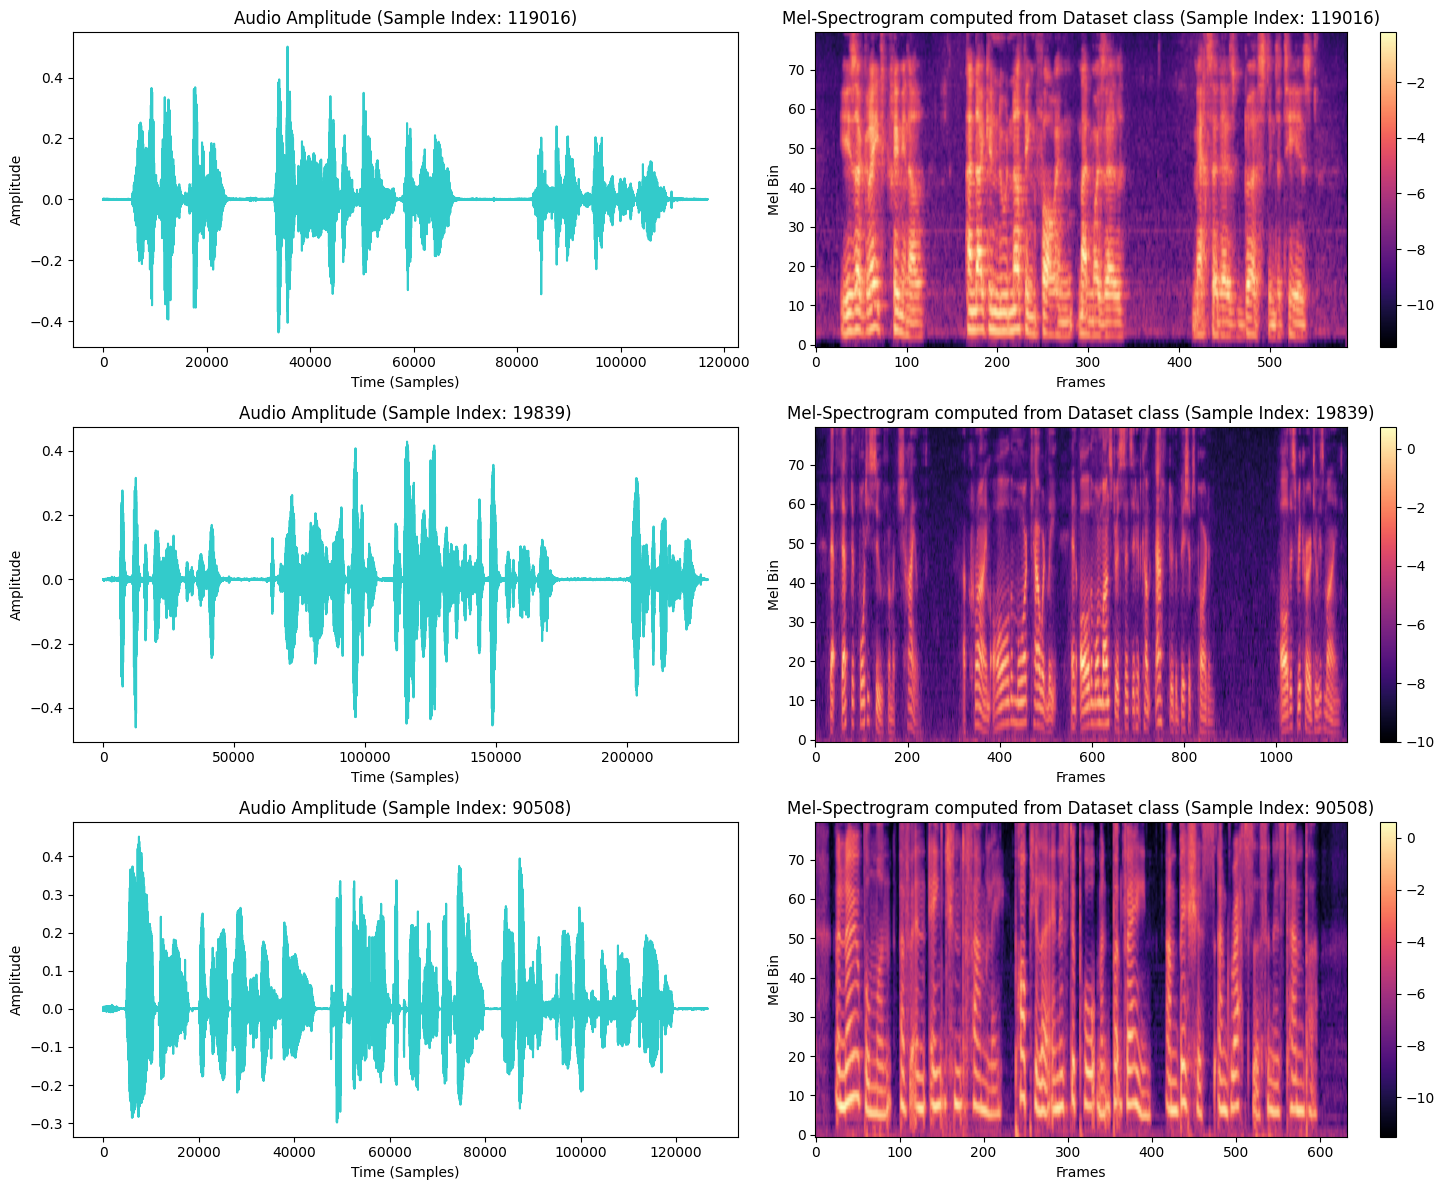

In [3]:

num_samples_to_plot = 3
sample_indices = random.sample(range(len(dataset)), num_samples_to_plot)

# Configurado para 2 colunas e largura ajustada para caber os dois gráficos
fig, axes = plt.subplots(num_samples_to_plot, 2, figsize=(15, 4 * num_samples_to_plot))
if num_samples_to_plot == 1:
    axes = [axes]

for idx, ax_row in zip(sample_indices, axes):
    sample = dataset[idx]
    mel = sample[1].numpy()  
    
    if isinstance(dataset, Subset):
        file_info = dataset.dataset.files[dataset.indices[idx]]
    else:
        file_info = dataset.files[idx]
        
    data = torch.load(file_info["mel_path"], map_location="cpu")
    waveform = data["waveform"].squeeze().numpy()

    ax_row[0].plot(waveform, color='c', alpha=0.8)
    ax_row[0].set_title(f"Audio Amplitude (Sample Index: {idx})")
    ax_row[0].set_ylabel("Amplitude")
    ax_row[0].set_xlabel("Time (Samples)")

    im = ax_row[1].imshow(mel, origin='lower', aspect='auto', cmap='magma')
    ax_row[1].set_title(f"Mel-Spectrogram computed from Dataset class (Sample Index: {idx})")
    ax_row[1].set_ylabel("Mel Bin")
    ax_row[1].set_xlabel("Frames")
    fig.colorbar(im, ax=ax_row[1])

plt.tight_layout()
plt.show()

In [4]:
# ==========================================
# 4. FEATURE EXTRACTION FOR STATISTICS & CLUSTERING
# ==========================================
# To perform PCA, Clustering, and Statistics over variable length audio,
# we extract the mean over the time-axis to create a fixed-size 80-dimensional embedding per file.

MAX_SAMPLES = 2000 # Limit to 2000 to prevent OOM errors during TSNE/PCA
samples_to_process = min(MAX_SAMPLES, len(dataset))
random.seed(42)
selected_indices = random.sample(range(len(dataset)), samples_to_process)

spectral_embeddings = []

print(f"Extracting temporal-averaged mel embeddings for {samples_to_process} samples using the Dataset class...")
for idx in tqdm(selected_indices):
    # Fetch the sample from the dataset class
    sample = dataset[idx]
    mel = sample[1]  # The on-the-fly computed Mel-spectrogram tensor
    
    # Collapse time dimension (Mean pooling)
    time_averaged_mel = mel.mean(dim=1).numpy() # Shape: (80,)
    spectral_embeddings.append(time_averaged_mel)

X = np.stack(spectral_embeddings) # Matrix of shape (N, 80)
print(f"Extracted feature matrix shape: {X.shape}")

Extracting temporal-averaged mel embeddings for 2000 samples using the Dataset class...


100%|██████████| 2000/2000 [00:50<00:00, 39.85it/s] 

Extracted feature matrix shape: (2000, 80)


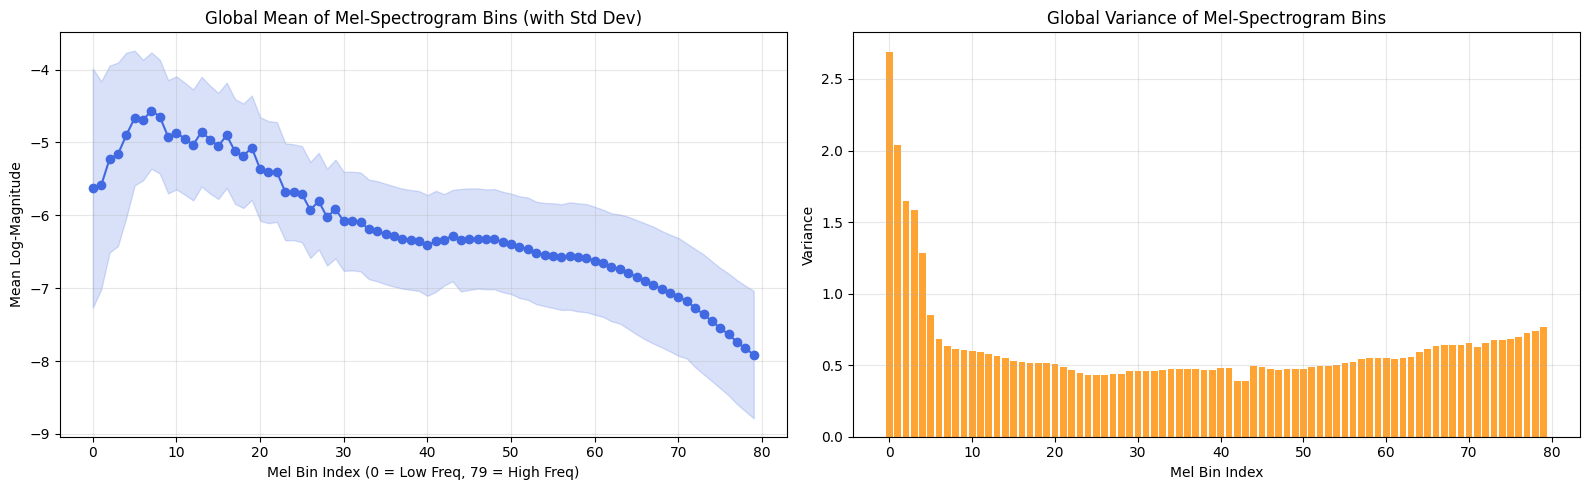

In [5]:
# ==========================================
# 5. SPECTRAL STATISTICS
# ==========================================
# Calculate mean and variance across the dataset for each Mel frequency bin
global_mean = np.mean(X, axis=0)
global_variance = np.var(X, axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(global_mean, marker='o', color='royalblue')
ax1.fill_between(range(80), global_mean - np.sqrt(global_variance), global_mean + np.sqrt(global_variance), color='royalblue', alpha=0.2)
ax1.set_title("Global Mean of Mel-Spectrogram Bins (with Std Dev)")
ax1.set_xlabel("Mel Bin Index (0 = Low Freq, 79 = High Freq)")
ax1.set_ylabel("Mean Log-Magnitude")
ax1.grid(True, alpha=0.3)

ax2.bar(range(80), global_variance, color='darkorange', alpha=0.8)
ax2.set_title("Global Variance of Mel-Spectrogram Bins")
ax2.set_xlabel("Mel Bin Index")
ax2.set_ylabel("Variance")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Running K-Means Clustering...


Running PCA...
Running t-SNE (this might take a few seconds)...


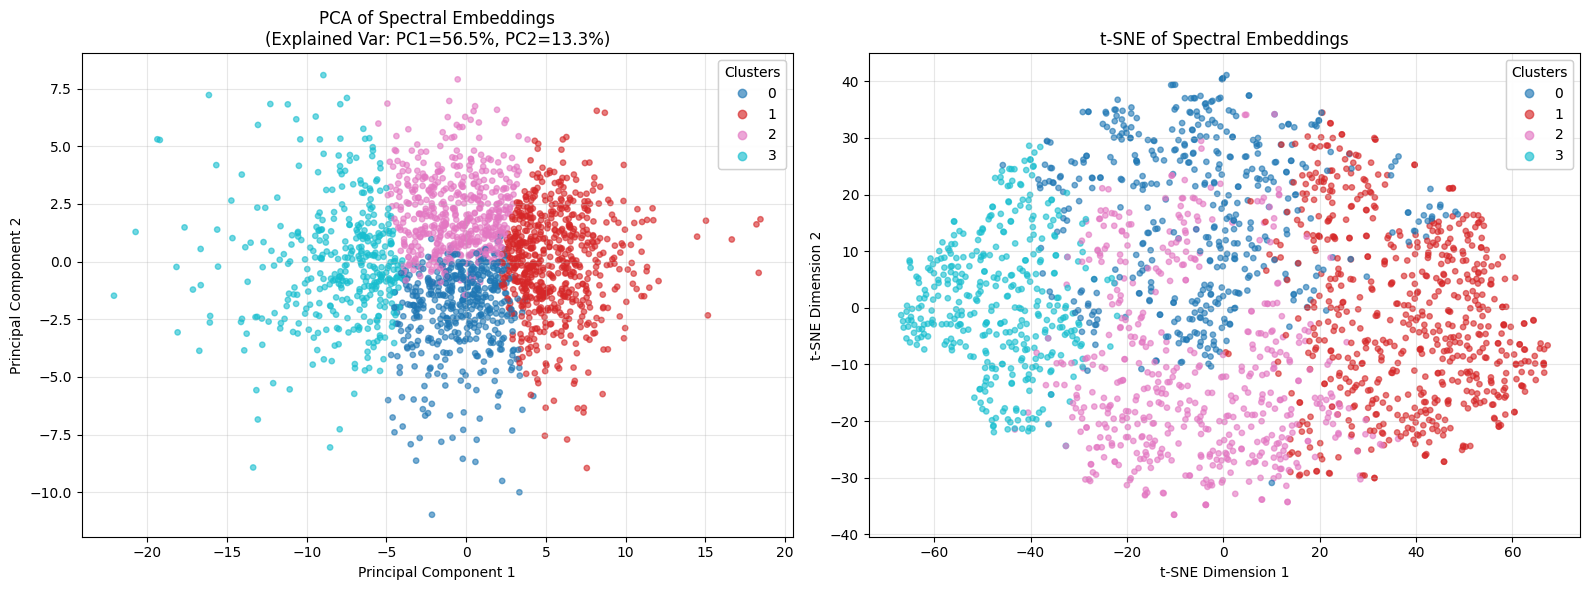

In [7]:
# ==========================================
# 6. SPECTRAL CLUSTERING (K-MEANS, PCA, t-SNE)
# ==========================================
NUM_CLUSTERS = 4

print("Running K-Means Clustering...")
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

print("Running PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
explained_var = pca.explained_variance_ratio_

print("Running t-SNE (this might take a few seconds)...")
# CORREÇÃO AQUI: max_iter=1000 em vez de n_iter=1000
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X)

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=15)
ax1.set_title(f"PCA of Spectral Embeddings\n(Explained Var: PC1={explained_var[0]*100:.1f}%, PC2={explained_var[1]*100:.1f}%)")
ax1.set_xlabel("Principal Component 1")
ax1.set_ylabel("Principal Component 2")
ax1.grid(True, alpha=0.3)
legend1 = ax1.legend(*scatter1.legend_elements(), title="Clusters")
ax1.add_artist(legend1)

scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=15)
ax2.set_title("t-SNE of Spectral Embeddings")
ax2.set_xlabel("t-SNE Dimension 1")
ax2.set_ylabel("t-SNE Dimension 2")
ax2.grid(True, alpha=0.3)
legend2 = ax2.legend(*scatter2.legend_elements(), title="Clusters")
ax2.add_artist(legend2)

plt.tight_layout()
plt.show()